# 🧠 PCA (주성분 분석) - Scikit-learn 예제

## 📌 개요
- PCA는 차원을 줄이는 기법
- 여러 feature를 “정보 손실 최소화”로 압축
- 시각화 및 전처리에 많이 사용

---

## 📦 전체 코드 (주석 포함)

설명 분산 비율:
[0.92461872 0.05306648]

누적 설명 분산:
[0.92461872 0.97768521]

PCA 변환 데이터 (앞 5개):
[[-2.68412563  0.31939725]
 [-2.71414169 -0.17700123]
 [-2.88899057 -0.14494943]
 [-2.74534286 -0.31829898]
 [-2.72871654  0.32675451]]

주성분 방향 (components):
[[ 0.36138659 -0.08452251  0.85667061  0.3582892 ]
 [ 0.65658877  0.73016143 -0.17337266 -0.07548102]]


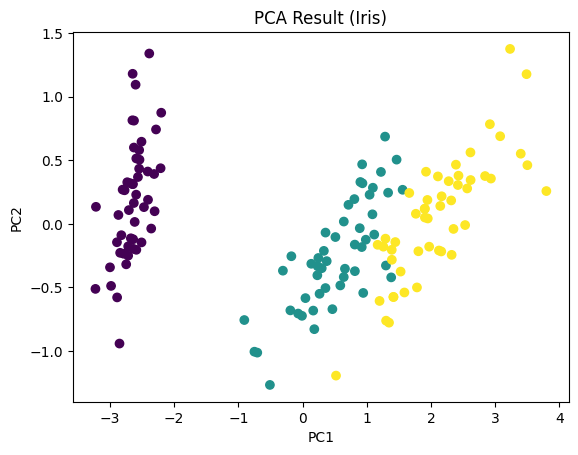

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

# 1️⃣ 데이터 로드
iris = load_iris()
X = iris.data
y = iris.target

# 2️⃣ PCA 적용 (2차원 축소)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# =========================
# 🔥 1. explained_variance_ratio_
# =========================

# # 1. 몇 개의 PC 쓸지 결정
# pca.explained_variance_ratio_
# PC1 → 92% 설명 (거의 핵심)
# PC2 → 5% 설명 (보조)
# PC1 하나만으로도 대부분 정보 유지 가능

print("설명 분산 비율:")
print(pca.explained_variance_ratio_)

# 👉 해석:
# 각 PC가 데이터를 얼마나 설명하는지



# =========================
# 🔥 2. 누적 분산
# =========================
# # 2. 데이터 구조 확인
# plt.scatter(...)
# [0.92, 0.97]
# 2개 쓰면 97% 정보 유지
# 95% 이상이면 충분
print("\n누적 설명 분산:")
print(np.cumsum(pca.explained_variance_ratio_))

# 👉 해석:
# 몇 개의 PC로 충분한지 판단


# =========================
# 🔥 3. PCA 변환 데이터
# =========================
print("\nPCA 변환 데이터 (앞 5개):")
print(X_pca[:5])

# 👉 해석:
# 기존 데이터가 새로운 좌표(PC 기준)로 바뀜


# =========================
# 🔥 4. components_
# =========================
# # 4. feature 의미 해석
# pca.components_

# X = iris.data
# feature 순서:
# [sepal_length, sepal_width, petal_length, petal_width]

# 4개 feature를 비슷한 비율로 합친 축
#예)PC1 = [0.5, 0.5, 0.5, 0.5]

#PC2 = [0.7, -0.2, 0.6, -0.3]
# 👉 해석:

# petal_length (+0.6), sepal_length (+0.7)
# sepal_width, petal_width는 음수 영향

# ✔ 3️⃣ components_
# [
#  [0.36, 0.08, 0.85, 0.36], 
#  [-0.66, -0.73, 0.17, 0.07] 
# ]

# 결론
# 🔥 4️⃣ 직관적으로 이해 (핵심)
# PC1

# 👉 “크기 축”

# 큰 꽃 vs 작은 꽃
# PC2

# 👉 “모양 축”

# 꽃잎 긴 타입 vs 짧은 타입
# 꽃받침 비율 차이

print("\n주성분 방향 (components):")
print(pca.components_)

# 👉 해석:
# 각 PC가 어떤 feature 조합인지 보여줌


# =========================
# 🔥 5. 시각화
# =========================
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Result (Iris)")
plt.show()



# 👉 해석:

# PC1
# 꽃잎 길이/너비 영향 큼
# → 가장 중요한 특징